<a href="https://colab.research.google.com/github/RishiYadav91/Gen-AI/blob/main/Experiment_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9335 - loss: 0.2169
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9756 - loss: 0.0784
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9821 - loss: 0.0568
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9848 - loss: 0.0495
Accuracy: 0.9847999811172485
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


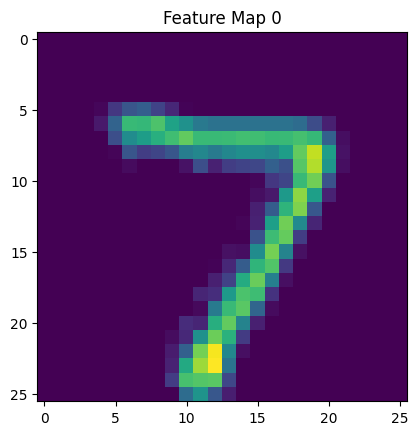

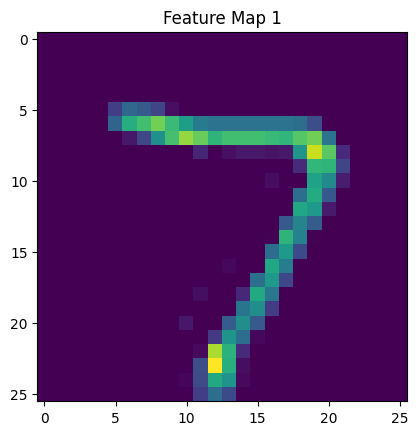

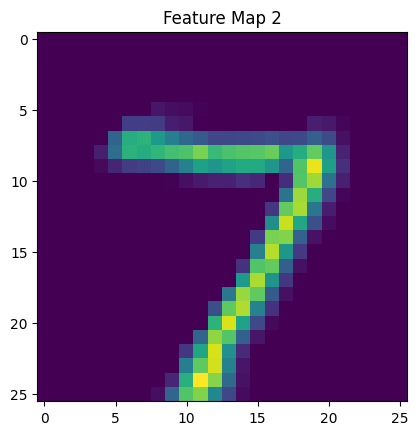

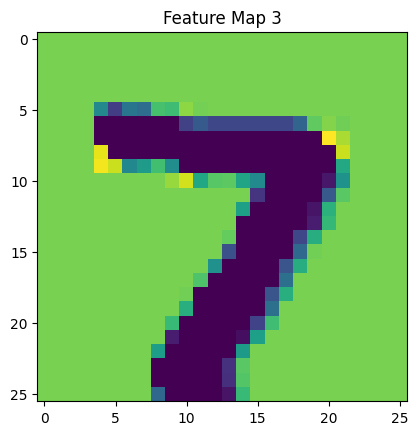

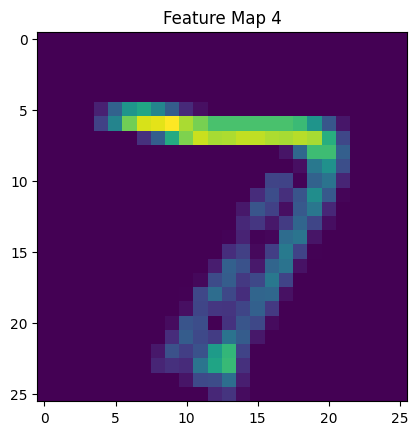

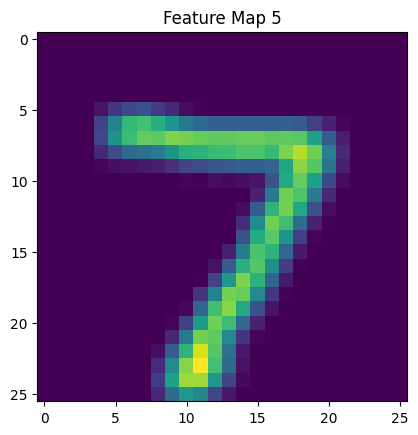

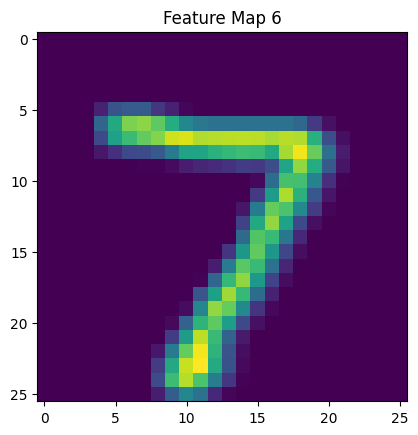

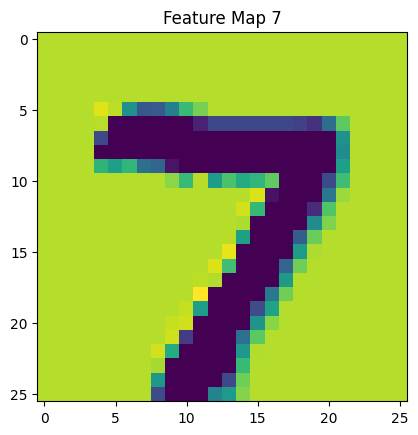

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

# Build CNN
model = models.Sequential([
layers.Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)),
layers.MaxPooling2D((2,2)),

layers.Conv2D(16, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

model.fit(x_train, y_train, epochs=3)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)
layer_outputs = [layer.output for layer in model.layers[:2]]
activation_model = tf.keras.models.Model(inputs=model.layers[0].input, outputs=layer_outputs)
sample = x_test[0].reshape(1,28,28,1)
activations = activation_model.predict(sample)
for i in range(8):
    plt.imshow(activations[0][0,:,:,i])
    plt.title(f"Feature Map {i}")
    plt.show()